# saptamana_4

=== ETAPA 1: Încărcarea datelor ===
Setul de date a fost încărcat cu succes!
Dimensiune: 1000 studenți (rânduri) și 8 caracteristici (coloane).

=== ETAPA 2: Structura datelor și tipurile de variabile ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None

Primele 5 rânduri din baza de date:
   gender race/ethnicity pa

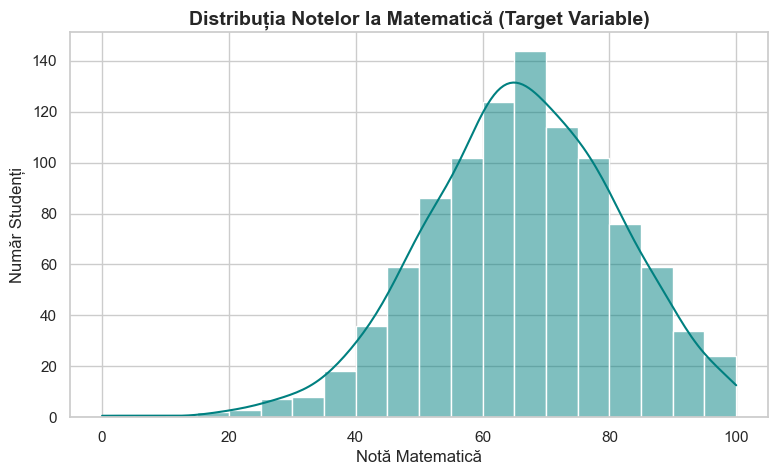

Graficul 1 (Distribuție) a fost salvat ca 'eda_distributie_math.png'


C:\Users\Alex Herman\AppData\Local\Temp\ipykernel_28116\1437980866.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test preparation course', y=target_col, palette='Set2')


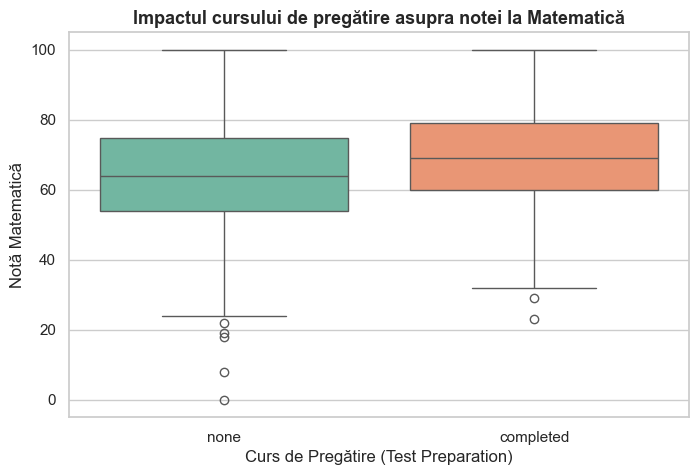

Graficul 2 (Boxplot Curs) a fost salvat ca 'eda_impact_curs.png'


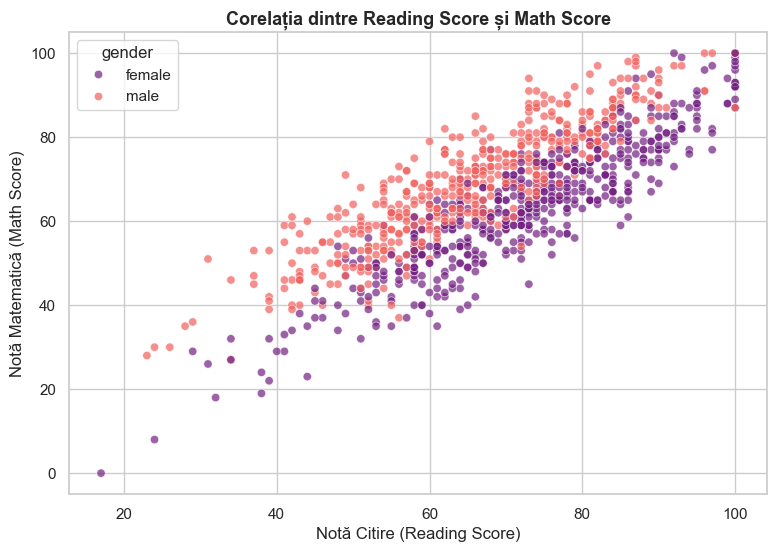

Graficul 3 (Scatter) a fost salvat ca 'eda_scatter_reading_math.png'


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setăm un stil curat pentru grafice
sns.set_theme(style="whitegrid")

# =====================================================================
# 📑 [SĂPTĂMÂNA 4] ÎNCĂRCARE, EXPLORARE ȘI CURĂȚARE DATE
# =====================================================================
print("=== ETAPA 1: Încărcarea datelor ===")

# Încărcăm fișierul tău real (StudentsPerformance.csv)
df = pd.read_csv('StudentsPerformance.csv')

# Definim variabila țintă pe care vrem să o prezicem (Regresie)
target_col = 'math score'

print(f"Setul de date a fost încărcat cu succes!")
print(f"Dimensiune: {df.shape[0]} studenți (rânduri) și {df.shape[1]} caracteristici (coloane).\n")

print("=== ETAPA 2: Structura datelor și tipurile de variabile ===")
print(df.info())

print("\nPrimele 5 rânduri din baza de date:")
print(df.head())

# =====================================================================
# 🧹 CURĂȚAREA DATELOR (Tratare duplicate și valori lipsă)
# =====================================================================
print("\n=== ETAPA 3: Curățarea datelor ===")

# 1. Verificăm și eliminăm duplicatele brute
duplicate_count = df.duplicated().sum()
print(f"Număr de rânduri duplicate găsite: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicatele au fost eliminate.")

# 2. Verificăm dacă există valori lipsă (NaN)
missing_values = df.isnull().sum()
print("\nValori lipsă per fiecare coloană:")
print(missing_values)

# Nota profesorului: Chiar dacă acest set specific de pe Kaggle nu are lipsuri brute,
# în documentație vei menționa că ai rulat verificarea de integritate structurală.

# =====================================================================
# 📊 ANALIZA EXPLORATORIE A DATELOR (EDA) - Grafice obligatorii
# =====================================================================
print("\n=== ETAPA 4: Generare Grafice pentru EDA ===")

# Grafic 1: Distribuția variabilei țintă (Math Score)
# Ajută la demonstrarea modului în care împrăștierea notelor respectă o distribuție normală
plt.figure(figsize=(9, 5))
sns.histplot(df[target_col], kde=True, color='teal', bins=20)
plt.title('Distribuția Notelor la Matematică (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Notă Matematică')
plt.ylabel('Număr Studenți')
plt.savefig('eda_distributie_math.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graficul 1 (Distribuție) a fost salvat ca 'eda_distributie_math.png'")

# Grafic 2: Influența cursului de pregătire asupra notei la matematică
# Analiză utilă pentru business/contextul problemei (Cine învață, ia note mai mari?)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='test preparation course', y=target_col, palette='Set2')
plt.title('Impactul cursului de pregătire asupra notei la Matematică', fontsize=13, fontweight='bold')
plt.xlabel('Curs de Pregătire (Test Preparation)')
plt.ylabel('Notă Matematică')
plt.savefig('eda_impact_curs.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graficul 2 (Boxplot Curs) a fost salvat ca 'eda_impact_curs.png'")

# Grafic 3: Relația dintre Reading Score și Math Score împărțită pe Gen
# Arată corelațiile puternice dintre abilitățile de citire și cele de matematică
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='reading score', y='math score', hue='gender', alpha=0.7, palette='magma')
plt.title('Corelația dintre Reading Score și Math Score', fontsize=13, fontweight='bold')
plt.xlabel('Notă Citire (Reading Score)')
plt.ylabel('Notă Matematică (Math Score)')
plt.savefig('eda_scatter_reading_math.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graficul 3 (Scatter) a fost salvat ca 'eda_scatter_reading_math.png'")